In [1]:
import pandas as pd

file_path = "../data/processed/cleaned_data.csv"

df = pd.read_csv(file_path)

print("Cleaned dataset loaded successfully!")
print("Shape:", df.shape)

Cleaned dataset loaded successfully!
Shape: (100000, 24)


In [2]:
print(df["Revenue"].describe())

count    100000.000000
mean        393.351350
std         297.154653
min          10.653198
25%         155.415176
50%         313.349100
75%         573.063568
max        1443.134985
Name: Revenue, dtype: float64


In [3]:
features = [
    "Units",
    "Cost_Price",
    "Selling_Price",
    "Month",
    "Day_of_Week",
    "Customer_Age",
    "Loyalty_Flag"
]

X = df[features]
y = df["Revenue"]

print("Features:", X.columns.tolist())
print("X shape:", X.shape)
print("y shape:", y.shape)

Features: ['Units', 'Cost_Price', 'Selling_Price', 'Month', 'Day_of_Week', 'Customer_Age', 'Loyalty_Flag']
X shape: (100000, 7)
y shape: (100000,)


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (80000, 7)
Testing data: (20000, 7)


In [5]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [6]:
y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print(y_pred[:10])

Predictions generated successfully!
[139.40457703 443.86117466 671.98480043 533.68783292 -30.91855239
 453.84119704  35.96686844 857.12707241 594.93480766 524.8134313 ]


In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 72.2300884285847
MSE : 9818.220494330923
RMSE: 99.08693402427447
R²  : 0.8898704442913377


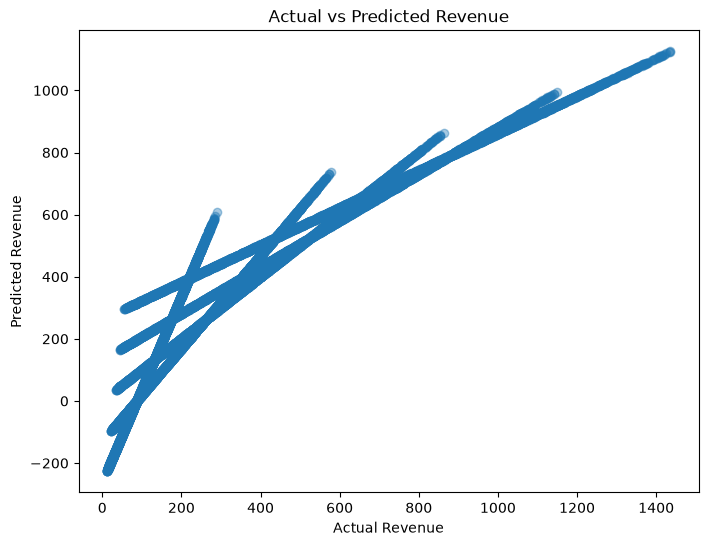

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.4)

plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Actual vs Predicted Revenue")

plt.show()

In [9]:
coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})

print(coefficients)

         Feature  Coefficient
0          Units   130.994898
1     Cost_Price    -0.066931
2  Selling_Price     3.047460
3          Month    -0.108281
4    Day_of_Week     0.118900
5   Customer_Age     0.051488
6   Loyalty_Flag     0.358989


In [10]:
import joblib

joblib.dump(model, "../models/regression/linear_regression.pkl")

print("Linear Regression model saved successfully!")

Linear Regression model saved successfully!
